In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 


In [12]:
df = pd.read_excel("BaseDados.xlsx")
display(df)
#M significa peso acumulado dos bicho 
#R significa toneladas de racao total
preco_massa = 8
preco_racao = 0.50

,t,M,R
0,1,53,77
1,2,115,168
2,3,180,328
3,4,257,550
4,5,338,829
5,6,424,1160
6,7,517,1540
7,8,597,1950
8,9,683,2400
9,10,774,2840


In [3]:
t = df["t"] #pegamos a coluna t do dataframe, como e uma coluna vira um series
type(t)

pandas.Series

In [4]:
t = df["t"].values #transformando num vetor
type(t)

numpy.ndarray

In [5]:
M = df["M"].values #coluna de massa virando array
R = df["R"].values #coluna de racao virando array

In [6]:
grau_m = 2 #coeficinte da massa
grau_r = 2 #coeficiente da racao

coef_m = np.polyfit(x = t, y = M, deg = grau_m)
print(coef_m) #mmq da massa em funcao do tempo

coef_r = np.polyfit(x = t, y = R, deg = grau_m)
print(coef_r) #mmq da racao em funcao do tempo

#Transforma em uma funcao matematica, se passar massa_ajustada(num) ele retorna o valor numerico
#isso e oq faz o poly1d
massa_ajustada = np.poly1d(coef_m)
racao_ajustada = np.poly1d(coef_r)

[ -0.37112887  83.07642358 -51.72727273]
[ 20.65734266  84.06993007 -77.72727273]


In [7]:
#funcao pra medir o erro geral
#aprender por fora como funciona o Rˆ2
def r2(y, y_hat):
    """"
    Calcula um numero referente ao acerto da funcao aos dados
    y: dados reais
    y_hat: dados teoricos
    
    """
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)


In [8]:
print(f"r2 massa: {r2(M, massa_ajustada(t))}")

print(f"r2 racao: {r2(R, racao_ajustada(t))}")

r2 massa: 0.9956971954908909
r2 racao: 0.9993879542529603


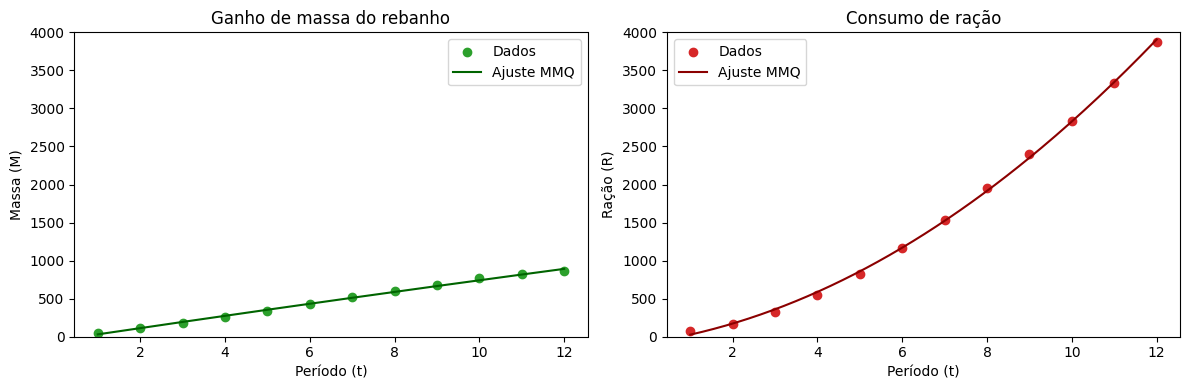

In [9]:
#comando pra rodar o grafico
t_fino = np.linspace(t.min(), t.max(), 200)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(t, M, color='tab:green', label='Dados')
ax[0].plot(t_fino, massa_ajustada(t_fino), color='darkgreen', label='Ajuste MMQ')
ax[0].set_title('Ganho de massa do rebanho')
ax[0].set_xlabel('Período (t)'); ax[0].set_ylabel('Massa (M)'); ax[0].legend()
ax[0].set_ylim(0, 4000)

ax[1].scatter(t, R, color='tab:red', label='Dados')
ax[1].plot(t_fino, racao_ajustada(t_fino), color='darkred', label='Ajuste MMQ')
ax[1].set_title('Consumo de ração')
ax[1].set_xlabel('Período (t)'); ax[1].set_ylabel('Ração (R)'); ax[1].legend()
ax[1].set_ylim(0, 4000)

plt.tight_layout(); plt.show()


In [10]:
# Função de lucro: receita da massa vendida - custo da ração consumida
def lucro(t):
    return preco_massa * massa_ajustada(t) - preco_racao * racao_ajustada(t)

# Extrapolando para o futuro (além dos dados observados) até o pico aparecer
t_futuro = np.linspace(t.min(), t.max() + 20, 600)
L = lucro(t_futuro)

# Período ótimo: onde o lucro estimado é máximo
i_otimo = np.argmax(L)
t_otimo = t_futuro[i_otimo]
lucro_otimo = L[i_otimo]

print(f"Período ideal de abate: t ≈ {t_otimo:.2f}")
print(f"Lucro estimado no ótimo: R$ {lucro_otimo:.2f}")

Período ideal de abate: t ≈ 23.41
Lucro estimado no ótimo: R$ 6912.05


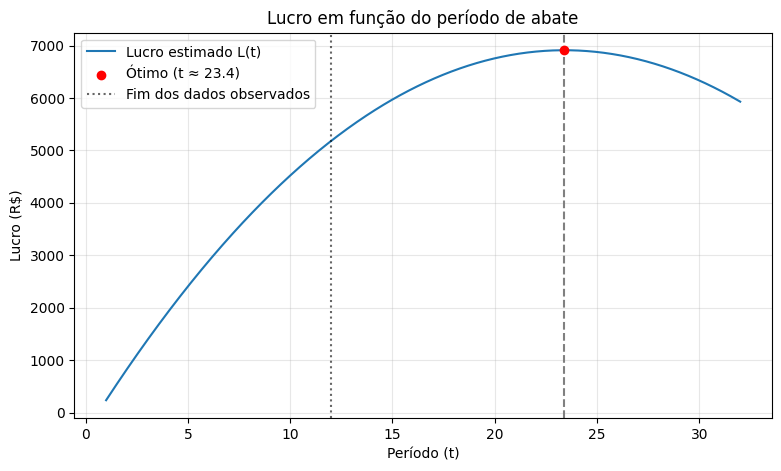

In [11]:
#grafico final
plt.figure(figsize=(9, 5))
plt.plot(t_futuro, L, color='tab:blue', label='Lucro estimado L(t)')
plt.axvline(t_otimo, color='gray', linestyle='--')
plt.scatter([t_otimo], [lucro_otimo], color='red', zorder=5,
            label=f'Ótimo (t ≈ {t_otimo:.1f})')
plt.axvline(t.max(), color='black', linestyle=':', alpha=0.6,
            label='Fim dos dados observados')
plt.title('Lucro em função do período de abate')
plt.xlabel('Período (t)'); plt.ylabel('Lucro (R$)')
plt.legend(); plt.grid(alpha=0.3); plt.show()